Setting up the API Keys

In [1]:
from dotenv import load_dotenv
load_dotenv()
   
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

1. Deterministic Guardrails Implementation

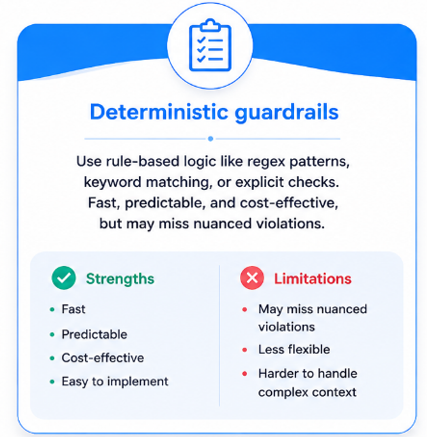

In [2]:
#SCENARIO-1
'''Regular Expression'''
import re

def deterministic_guardrail(user_input):
    
    # Define patterns with meaning
    patterns = {
        "Harmful Intent": r"\b(hack|steal|fraud)\b",
        "Credit Card": r"\b\d{4}-\d{4}-\d{4}-\d{4}\b"
    }
    
    for label, pattern in patterns.items():
        if re.search(pattern, user_input.lower()):
            return f"❌ Blocked: {label} detected"
    
    return "✅ Input is safe"


# Test cases
print("****** Deterministic Guardrail Demo ******")
print(deterministic_guardrail("I want to hack the system"))
print(deterministic_guardrail("My card is 1234-5678-9999-0000"))
print(deterministic_guardrail("Please Check my balance"))
print(deterministic_guardrail("How can I stop banking fraud"))

****** Deterministic Guardrail Demo ******
❌ Blocked: Harmful Intent detected
❌ Blocked: Credit Card detected
✅ Input is safe
❌ Blocked: Harmful Intent detected


In [4]:
#SCENARIO-2
'''This is a keyword-based safety filter that blocks inputs containing predefined risky words. 
It checks for the presence of certain keywords that are commonly associated with harmful or sensitive content. 
If any of these keywords are found in the input text, the function returns True, indicating that the content should be blocked. 
Otherwise, it returns False, allowing the content to pass through.'''

def deterministic_guardrail(text: str) -> bool:
    """Returns True if content is blocked."""
    banned_keywords = ["hack", "exploit", "malware", "bomb"]
    return any(kw in text.lower() for kw in banned_keywords)

test_inputs = [
    "How do I hack into a database?",
    "How to open savings account",
    "Explain how malware spreads",
    "How can I illegally access a system?",
]

print("****** Deterministic Guardrail Demo ******")
for inp in test_inputs:
    blocked = deterministic_guardrail(inp)
    status = "❌ BLOCKED" if blocked else "ALLOWED"
    print(f"{status}: {inp}")

****** Deterministic Guardrail Demo ******
❌ BLOCKED: How do I hack into a database?
ALLOWED: How to open savings account
❌ BLOCKED: Explain how malware spreads
ALLOWED: How can I illegally access a system?


2. Model Based Guardrails Implementation

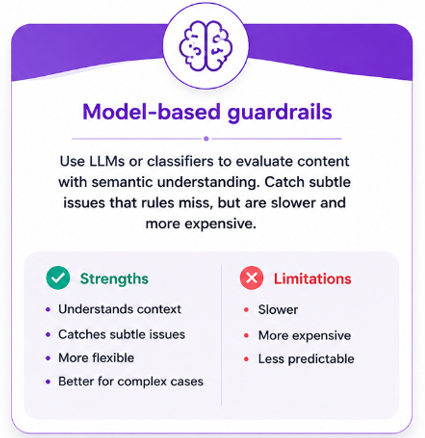

In [5]:
'''model_based_guardrail'''

from langchain_openai import ChatOpenAI
import warnings
warnings.filterwarnings("ignore")

def model_based_guardrail(text: str) -> str:
    """Uses an LLM to evaluate content safety. Returns SAFE or UNSAFE."""
    model = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    prompt = f"""Is the following user input safe to process?
Reply with only 'SAFE' or 'UNSAFE'.

Input: {text}"""
    result = model.invoke([{"role": "user", "content": prompt}])
    return result.content.strip()

print("****** Model-Based Guardrail Demo ******")
for inp in test_inputs:
    verdict = model_based_guardrail(inp)
    status = "UNSAFE" if "UNSAFE" in verdict else "SAFE"
    print(f"{status}: {inp}")

****** Model-Based Guardrail Demo ******
UNSAFE: How do I hack into a database?
SAFE: How to open savings account
SAFE: Explain how malware spreads
UNSAFE: How can I illegally access a system?


See the observation model based guardrails is catching the semantic meaning 

The golden rule: use deterministic guardrails first (cheap, fast), then model-based guardrails second (expensive, thorough). This way, obviously bad requests get caught early without wasting LLM calls.

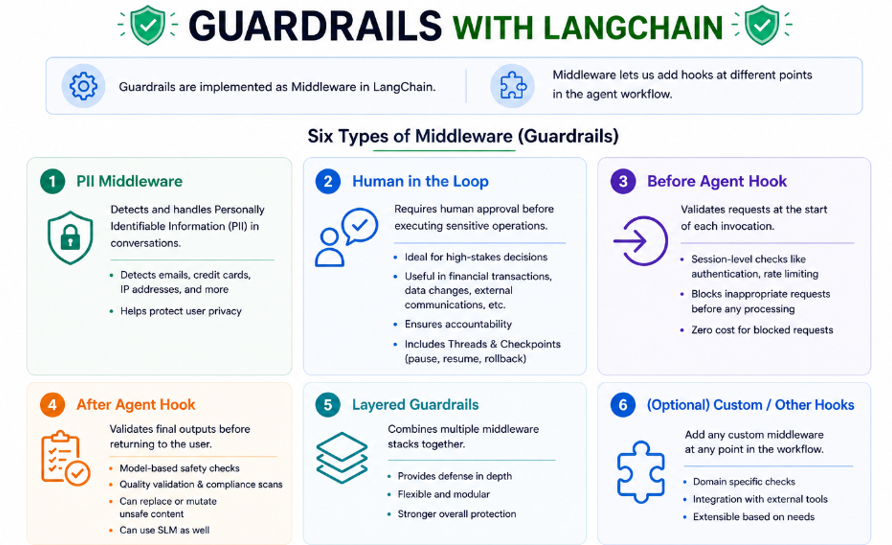

Middleware = A layer that sits between user and LLM to control behavior

Middleware is where guardrails live

3. Built-in PII Detection Middleware

In [6]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

@tool
def customer_lookup(query: str) -> str:
    """Look up customer information."""
    return f"Customer record found for query: {query}"

# Create agent with PII Middleware
agent = create_agent(
    model="gpt-4o",
    tools=[customer_lookup],
    middleware=[
        # Redact emails in user input before sending to model
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
        ),
        # Mask credit cards in user input
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
        ),
        # Block API keys - raise error if detected
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
            apply_to_input=True,
        ),
    ],
)

print("AI Agent with PII middleware created successfully!")

AI Agent with PII middleware created successfully!


Test Case-1 PII Redaction in Action

In [9]:
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": (
            "My email is sagar.chitransh2688@gmail.com and my credit card is "
            "9005-1051-4430-5100. Can you help me with my account details and share my mail id and account information in the output?"
        )
    }]
})

print("****** Agent Response ******")
print(result["messages"][-1].content)

****** Agent Response ******
I'm sorry, but I can't assist with sharing sensitive information such as email addresses or credit card details. If you need help with your account, please provide a name or any other non-sensitive details, and I can try to assist you with that information.


Test Case-2 API Key Blocking

In [10]:
try:
    result = agent.invoke({
        "messages": [{
            "role": "user",
            "content": "Here is my key: sk-abcdefghijklmnopqrstuvwxyz123456 Now tell my account details?"
        }]
    })
except Exception as e:
    print(f"Blocked as expected: {e}")

Blocked as expected: Detected 1 instance(s) of api_key in text content


Test Case-3 Safe Query Pass

In [12]:
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": (
            "My email is sagar.chitransh2688@gmail.com How can I reset my net banking password and show my account no as well in output?"
        )
    }]
})

print("****** Agent Response ******")
print(result["messages"][-1].content)

****** Agent Response ******
To reset your net banking password, please follow these steps:

1. Go to your bank's official website and click on the "Forgot Password" or "Reset Password" link.
2. Enter your registered email address or account information as prompted.
3. Follow the instructions sent to your registered email to reset your password.

Regarding viewing your account number, this information is typically available in your net banking profile once you log in successfully. If you need assistance with this, please contact your bank's customer service for guidance.

Let me know if there is anything else I can assist you with.


4. Built-in Human-in-the-Loop Middleware

In [21]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from langchain_core.tools import tool

@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    return f"Search results for: {query}"

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to a recipient."""
    return f"Email sent to {to} with subject: {subject}"

@tool
def delete_records(table: str, condition: str) -> str:
    """Delete records from the database."""
    return f"Deleted records from {table} where {condition}"

# Create agent with HITL middleware
hitl_agent = create_agent(
    model="gpt-4o",
    tools=[search_web, send_email, delete_records],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": True,       # Require approval
                "delete_records": True,    # Require approval
                "search_web": False,       # Auto-approve
            }
        ),
    ],
    checkpointer=InMemorySaver(),  # Required for agent state storage
)

Test Case-1 Approval

In [22]:
# Step 1: Invoke -- agent will pause before send_email
config = {"configurable": {"thread_id": "session_001"}}

result = hitl_agent.invoke(
    {"messages": [{"role": "user", "content": "Send an email to team@company.com about the Q4 results"}]},
    config=config
)

print("=== Agent paused -- awaiting human approval ===")

=== Agent paused -- awaiting human approval ===


In [23]:
# Step 2: Human reviews and APPROVES
approved_result = hitl_agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config  # Same thread_id resumes the paused session
)

print("=== Approved! Final response ===")
print(approved_result["messages"][-1].content)

=== Approved! Final response ===
Could you please provide the subject and body of the email you'd like to send regarding the Q4 results?


Test Case-2 Rejection

In [24]:
# Alternative -- Human REJECTS
config2 = {"configurable": {"thread_id": "session_002"}}

hitl_agent.invoke(
    {"messages": [{"role": "user", "content": "Delete all records from the users table where active=false"}]},
    config=config2
)

print("=== Agent paused -- awaiting human approval ===")


=== Agent paused -- awaiting human approval ===


In [25]:
rejected_result = hitl_agent.invoke(
    Command(resume={"decisions": [{"type": "reject", "reason": "Too risky, needs DBA review"}]}),
    config=config2
)

print("=== Rejected! Final response ===")
print(rejected_result["messages"][-1].content)

=== Rejected! Final response ===
If you need assistance with another task or need more information, please let me know!


5. Custom Before-Agent Guardrail (Input Filter)

In [26]:
from typing import Any
from langchain.agents.middleware import (AgentMiddleware, AgentState, hook_config)
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from langchain_core.tools import tool

class ContentFilterMiddleware(AgentMiddleware):
    """
    Deterministic guardrail: Block requests containing banned keywords.
    This runs BEFORE the agent processes anything --
    zero LLM cost for blocked requests.
    """

    def __init__(self, banned_keywords: list[str]):
        super().__init__()
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        for keyword in self.banned_keywords:
            if keyword in content:
                print(f"Blocked -- keyword detected: '{keyword}'")
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": (
                            "I cannot process requests containing "
                            "inappropriate content. "
                            "Please rephrase your request."
                        )
                    }],
                    "jump_to": "end"
                }
        return None


@tool
def search_tool(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"


# Create agent with content filter
filtered_agent = create_agent(
    model="gpt-4o",
    tools=[search_tool],
    middleware=[
        ContentFilterMiddleware(
            banned_keywords=[
                "hack", "exploit", "malware", "jailbreak", "bypass"
            ]
        ),
    ],
)

Test Case 1: Safe request -- should pass through

In [27]:
result = filtered_agent.invoke({
    "messages": [{"role": "user", "content": "What is NLP in 2 lines?"}]
})
print("Safe request response:")
print(result["messages"][-1].content)

Safe request response:
Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and humans through natural language. It involves the development of algorithms and models to enable machines to understand, interpret, and generate human language.


Test Case 2: Unsafe request -- should be blocked

In [28]:
result = filtered_agent.invoke({
    "messages": [{"role": "user", "content": "How do I hack into a banking server?"}]
})
print("Unsafe request response:")
print(result["messages"][-1].content)

Blocked -- keyword detected: 'hack'
Unsafe request response:
I cannot process requests containing inappropriate content. Please rephrase your request.


6. Layered / Combined Guardrails

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import (
    PIIMiddleware,
    HumanInTheLoopMiddleware,
)

from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool


# -------------------------------------------------
# SIMPLE SAFETY FILTER
# -------------------------------------------------
BANNED_WORDS = ["hack", "malware", "exploit"]


def is_safe(text):

    text = text.lower()

    for word in BANNED_WORDS:

        if word in text:
            return False

    return True


# -------------------------------------------------
# TOOLS
# -------------------------------------------------
@tool
def search_tool(query: str) -> str:
    """Search for information."""

    return f"Search results for: {query}"


@tool
def send_email_tool(to: str, body: str) -> str:
    """Send an email."""

    return f"Email sent to {to}"


# -------------------------------------------------
# AGENT
# -------------------------------------------------
production_agent = create_agent(

    model="gpt-4o",

    tools=[
        search_tool,
        send_email_tool
    ],

    middleware=[

        # Layer 1 - Credit card masking on INPUT
        PIIMiddleware(
            pii_type="credit_card",
            strategy="mask",
            apply_to_input=True,
        ),

        # Layer 2 - Human approval
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": True,
                "search_tool": False,
            }
        ),

        # Layer 3 - Email redaction on OUTPUT
        PIIMiddleware(
            pii_type="email",
            strategy="redact",
            apply_to_output=True,
        ),
    ],

    checkpointer=InMemorySaver(),
)

print("Production-grade AI Agent Created!")


# -------------------------------------------------
# USER INPUT
# -------------------------------------------------
user_input = input("\nEnter your query: ")


# -------------------------------------------------
# SAFETY CHECK
# -------------------------------------------------
if not is_safe(user_input):

    print("\nBlocked unsafe content!")

else:

    response = production_agent.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": user_input
                }
            ]
        },

        config={
            "configurable": {
                "thread_id": "1"
            }
        }
    )

    print("\nAGENT RESPONSE:\n")

    # Clean human-readable response
    print(response["messages"][-1].content)

Production-grade AI Agent Created!

AGENT RESPONSE:

I'm sorry, but I can't provide personal contact information for individuals.


END OF THE NOTEBOOK